<a href="https://colab.research.google.com/github/alpacaYiChun/ML/blob/master/Siam1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

model_path = '/content/gdrive/My Drive/CLIP/siam.h5'

pic_path = '/content/gdrive/My Drive/publicstatic'

bgPath = '/content/gdrive/My Drive/CLIP'

Mounted at /content/gdrive


In [ ]:
#!pip install -q -U tensorflow

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
from pathlib import Path
from keras import applications
from keras import layers
from keras import losses
from keras import optimizers
from keras import metrics
from keras import Model
from keras.applications import resnet


target_shape = (200, 200)


## Load the dataset

We are going to load the *Totally Looks Like* dataset and unzip it inside the `~/.keras` directory
in the local environment.

The dataset consists of two separate files:

* `left.zip` contains the images that we will use as the anchor.
* `right.zip` contains the images that we will use as the positive sample (an image that looks like the anchor).

In [ ]:
cache_dir = Path(Path.home()) / ".keras"
anchor_images_path = cache_dir / "left"
positive_images_path = cache_dir / "right"

In [ ]:
!gdown --id 1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34
!gdown --id 1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW
!unzip -oq left.zip -d $cache_dir
!unzip -oq right.zip -d $cache_dir

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34
From (redirected): https://drive.google.com/uc?id=1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34&confirm=t&uuid=48445ac2-55b4-4843-b81d-11d0bd1722c3
To: /content/left.zip
100% 104M/104M [00:07<00:00, 14.5MB/s] 
/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW
From (redirected): https://drive.google.com/uc?id=1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW&confirm=t&uuid=ccc51e30-3c0e-4fbd-ae45-90c795d1ca2f
To: /content/right.zip
100% 10

In [ ]:
alg = "resnet"
epochs = 1000

## Preparing the data

We are going to use a `tf.data` pipeline to load the data and generate the triplets that we
need to train the Siamese network.

We'll set up the pipeline using a zipped list with anchor, positive, and negative filenames as
the source. The pipeline will load and preprocess the corresponding images.

In [ ]:

def preprocess_image(filename):
    """
    Load the specified file as a JPEG image, preprocess it and
    resize it to the target shape.
    """

    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_shape)
    if False:
      image = image / 255.0
    return image


def preprocess_triplets(anchor, positive, negative):
    """
    Given the filenames corresponding to the three images, load and
    preprocess them.
    """

    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )

Let's setup our data pipeline using a zipped list with an anchor, positive,
and negative image filename as the source. The output of the pipeline
contains the same triplet with every image loaded and preprocessed.

In [ ]:
# We need to make sure both the anchor and positive images are loaded in
# sorted order so we can match them together.
anchor_images = sorted(
    [str(anchor_images_path / f) for f in os.listdir(anchor_images_path)]
)

positive_images = sorted(
    [str(positive_images_path / f) for f in os.listdir(positive_images_path)]
)

image_count = len(anchor_images)

anchor_dataset = tf.data.Dataset.from_tensor_slices(anchor_images)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_images)

# To generate the list of negative images, let's randomize the list of
# available images and concatenate them together.
rng = np.random.RandomState(seed=42)
rng.shuffle(anchor_images)
rng.shuffle(positive_images)

negative_images = anchor_images + positive_images
np.random.RandomState(seed=32).shuffle(negative_images)

negative_dataset = tf.data.Dataset.from_tensor_slices(negative_images)
negative_dataset = negative_dataset.shuffle(buffer_size=4096)

dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(preprocess_triplets)

# Let's now split our dataset in train and validation.
train_dataset = dataset.take(round(image_count * 0.8))
val_dataset = dataset.skip(round(image_count * 0.8))

train_dataset = train_dataset.batch(32, drop_remainder=False)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(32, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


Let's take a look at a few examples of triplets. Notice how the first two images
look alike while the third one is always different.

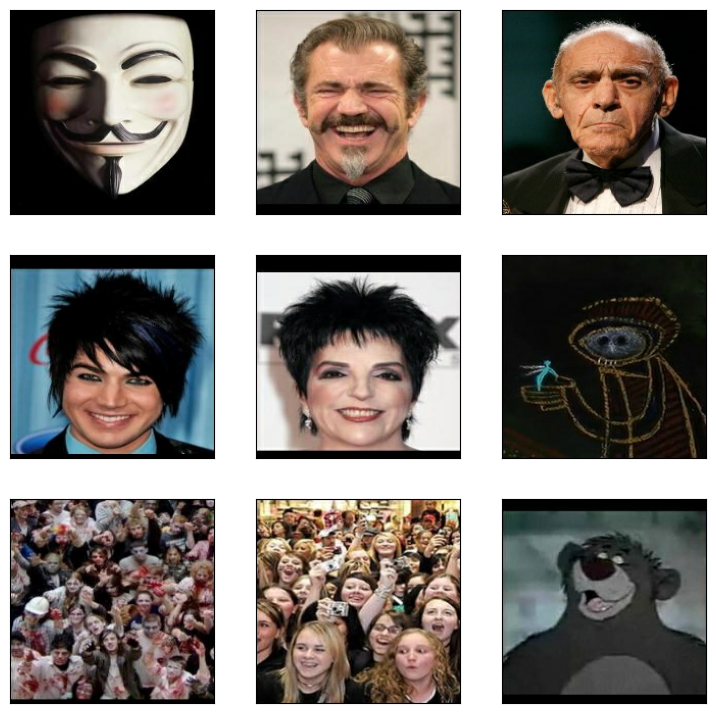

In [ ]:

def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], anchor[i])
        show(axs[i, 1], positive[i])
        show(axs[i, 2], negative[i])


visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])

## Setting up the embedding generator model

Our Siamese Network will generate embeddings for each of the images of the
triplet. To do this, we will use a ResNet50 model pretrained on ImageNet and
connect a few `Dense` layers to it so we can learn to separate these
embeddings.

We will freeze the weights of all the layers of the model up until the layer `conv5_block1_out`.
This is important to avoid affecting the weights that the model has already learned.
We are going to leave the bottom few layers trainable, so that we can fine-tune their weights
during training.

In [ ]:
def make_embedding_model():
  base_cnn = resnet.ResNet50(
      weights="imagenet", input_shape=target_shape + (3,), include_top=False
  )
  trainable = False
  for layer in base_cnn.layers:
      if layer.name == "conv5_block1_out":
          trainable = True
      layer.trainable = trainable
  flatten = layers.Flatten()(base_cnn.output)
  dense1 = layers.Dense(512, activation="relu")(flatten)
  dense1 = layers.BatchNormalization()(dense1)
  dense2 = layers.Dense(256, activation="relu")(dense1)
  dense2 = layers.BatchNormalization()(dense2)
  output = layers.Dense(256)(dense2)

  embedding = Model(base_cnn.input, output, name="Embedding")
  return embedding

In [ ]:
def make_conv_embedding_model():
  input = layers.Input(shape=target_shape + (3,))
  x = layers.SeparableConv2D(filters=64, kernel_size=5, strides=2, padding='same')(input)
  x = layers.Dropout(0.1)(x)
  x = layers.BatchNormalization()(x)
  f1 = layers.Activation("relu")(x)
  x = layers.SeparableConv2D(filters=64, kernel_size=5, strides=2, padding='same')(f1)
  x = layers.Dropout(0.1)(x)
  x = layers.BatchNormalization()(x)
  f2 = layers.Activation("relu")(x)
  f1_skip = layers.Conv2D(filters=64, kernel_size=1, strides=2, padding='same')(f1)
  f2 = layers.Add()([f2, f1_skip])
  x = layers.SeparableConv2D(filters=64, kernel_size=5, strides=2, padding='same')(f2)
  x = layers.Dropout(0.1)(x)
  x = layers.BatchNormalization()(x)
  f3 = layers.Activation("relu")(x)
  f2_skip = layers.Conv2D(filters=64, kernel_size=1, strides=2, padding='same')(f2)
  f3 = layers.Add()([f3, f2_skip])
  x = layers.SeparableConv2D(filters=64, kernel_size=5, strides=2, padding='same')(f3)
  x = layers.Dropout(0.1)(x)
  x = layers.BatchNormalization()(x)
  f4 = layers.Activation("relu")(x)
  f3_skip = layers.Conv2D(filters=64, kernel_size=1, strides=2, padding='same')(f3)
  f4 = layers.Add()([f4, f3_skip])
  f = layers.Flatten()(f4)
  f = layers.Dense(256)(f)
  f = layers.Dropout(0.1)(f)
  f = layers.BatchNormalization()(f)
  f = layers.Activation("relu")(f)
  return Model(input, f, name="Embedding")

In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size, stride):
        super().__init__()
        self.patch_size = patch_size
        self.stride = stride

    def call(self, images):
        input_shape = tf.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        #patches = tf.image.extract_patches(images, size=self.patch_size)
        patches = tf.image.extract_patches(
          images=images,
          sizes=[1, self.patch_size, self.patch_size, 1],
          strides=[1, self.stride, self.stride, 1],
          rates=[1, 1, 1, 1],
          padding='VALID'  # This means no padding is added and the patches are only extracted where they fully fit
        )
        batch_size = tf.shape(patches)[0]
        r = tf.shape(patches)[1]
        c = tf.shape(patches)[2]
        patches = tf.reshape(patches, [batch_size, r * c, self.patch_size * self.patch_size * channels])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.expand_dims(
            tf.range(start=0, limit=self.num_patches, delta=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

class Transformer(layers.Layer):
  def __init__(self, consistent_dims, num_heads, num_blocks):
    super().__init__()
    self.consistent_dims = consistent_dims
    self.num_heads = num_heads
    self.num_blocks = num_blocks
    self.attentions = []
    self.layer_normalization_1 = []
    self.layer_normalization_2 = []
    self.denses = []
    self.add1 = []
    self.add2 = []
    for i in range(num_blocks):
      self.attentions.append(layers.MultiHeadAttention(num_heads=num_heads, key_dim=consistent_dims, dropout=0.1))
      self.layer_normalization_1.append(layers.LayerNormalization(epsilon=1e-6))
      self.denses.append(layers.Dense(units=consistent_dims, activation="relu"))
      self.add1.append(layers.Add())
      self.layer_normalization_2.append(layers.LayerNormalization(epsilon=1e-6))
      self.add2.append(layers.Add())
  def call(self, inputs):
    x = inputs
    for i in range(self.num_blocks):
      base = x
      attn = self.attentions[i](x, x)
      sum1 = self.add1[i]([attn, base])
      norm1 = self.layer_normalization_1[i](sum1)
      f1 = self.denses[i](norm1)
      sum2 = self.add2[i]([f1, norm1])
      norm2 = self.layer_normalization_2[i](sum2)
      x = norm2
    return x

  def get_config(self):
    config = super().get_config()
    config.update({"consistent_dims": self.consistent_dims, "num_heads": self.num_heads, "num_blocks": self.num_blocks})
    return config

class VIT(layers.Layer):
  def __init__(self, patch_size, stride, embedding_dim, num_heads, num_blocks):
    super().__init__()
    castro = 625
    self.patch_size = patch_size
    self.embedding_dim = embedding_dim
    self.num_heads = num_heads
    self.num_blocks = num_blocks
    self.patch_layer = Patches(patch_size, stride)
    self.patch_encoder_layer = PatchEncoder(num_patches=castro, projection_dim=self.embedding_dim)
    self.transformer_layer = Transformer(consistent_dims=embedding_dim, num_heads=num_heads, num_blocks=num_blocks)
    self.global_average_pooling = layers.GlobalAveragePooling1D()
  def call(self, inputs):
    patches = self.patch_layer(inputs)
    encoded_patches = self.patch_encoder_layer(patches)
    ret = self.transformer_layer(encoded_patches)
    ret = self.global_average_pooling(ret)
    return ret

def make_vit_embedding_model():
  input = layers.Input(shape=target_shape+(3,), name="input_layer")
  vit = VIT(patch_size=8, stride=8, embedding_dim=128, num_heads=8, num_blocks=1)(input)
  return Model(input, vit, name="VIT")


## Setting up the Siamese Network model

The Siamese network will receive each of the triplet images as an input,
generate the embeddings, and output the distance between the anchor and the
positive embedding, as well as the distance between the anchor and the negative
embedding.

To compute the distance, we can use a custom layer `DistanceLayer` that
returns both values as a tuple.

In [ ]:

class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        pos_dot_product = tf.reduce_sum(tf.multiply(anchor, positive), axis=-1)
        neg_dot_product = tf.reduce_sum(tf.multiply(anchor, negative), axis=-1)
        # Calculate the norm (magnitude) of each vector
        anchor_norm = tf.norm(anchor, axis=-1)
        positive_norm = tf.norm(positive, axis=-1)
        negative_norm = tf.norm(negative, axis=-1)

        # Calculate the cosine similarity
        pos_cosine_similarity = pos_dot_product / (anchor_norm * positive_norm)
        neg_cosine_similarity = neg_dot_product / (anchor_norm * negative_norm)
        ap_distance = tf.reduce_sum(tf.square(anchor - positive), -1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)

if alg == "resnet":
  embedding = make_embedding_model()
elif alg == "vit":
  embedding = make_vit_embedding_model()
else:
  embedding = make_conv_embedding_model()

anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

anchor_input = resnet.preprocess_input(anchor_input)
positive_input = resnet.preprocess_input(positive_input)
negative_input = resnet.preprocess_input(negative_input)

distances = DistanceLayer()(
    embedding(anchor_input),
    embedding(positive_input),
    embedding(negative_input),
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)

94765736/94765736 [==============================] - 5s 0us/step


## Putting everything together

We now need to implement a model with custom training loop so we can compute
the triplet loss using the three embeddings produced by the Siamese network.

Let's create a `Mean` metric instance to track the loss of the training process.

In [ ]:

class SiameseModel(Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]


## Training

We are now ready to train our model.

Finally, we can compute the cosine similarity between the anchor and positive
images and compare it with the similarity between the anchor and the negative
images.

We should expect the similarity between the anchor and positive images to be
larger than the similarity between the anchor and the negative images.

Epoch 1/1000
151/151 [==============================] - ETA: 0s - loss: 0.4940

151/151 [==============================] - 102s 528ms/step - loss: 0.4940 - val_loss: 0.3980
Epoch 2/1000
151/151 [==============================] - ETA: 0s - loss: 0.3997

151/151 [==============================] - 74s 488ms/step - loss: 0.3997 - val_loss: 0.3787
Epoch 3/1000
151/151 [==============================] - ETA: 0s - loss: 0.3789

151/151 [==============================] - 75s 500ms/step - loss: 0.3789 - val_loss: 0.3474
Epoch 4/1000
151/151 [==============================] - ETA: 0s - loss: 0.3604

151/151 [==============================] - 76s 501ms/step - loss: 0.3604 - val_loss: 0.3524
Epoch 5/1000
151/151 [==============================] - ETA: 0s - loss: 0.3524

...

151/151 [==============================] - 73s 482ms/step - loss: 0.0128 - val_loss: 0.2021
Epoch 999/1000
151/151 [==============================] - ETA: 0s - loss: 0.0167

151/151 [==============================] - 74s 490ms/step - loss: 0.0167 - val_loss: 0.2157
Epoch 1000/1000
151/151 [==============================] - ETA: 0s - loss: 0.0126

151/151 [==============================] - 74s 490ms/step - loss: 0.0126 - val_loss: 0.2223


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Positive similarity: 0.9817624
Negative similarity 0.9831039


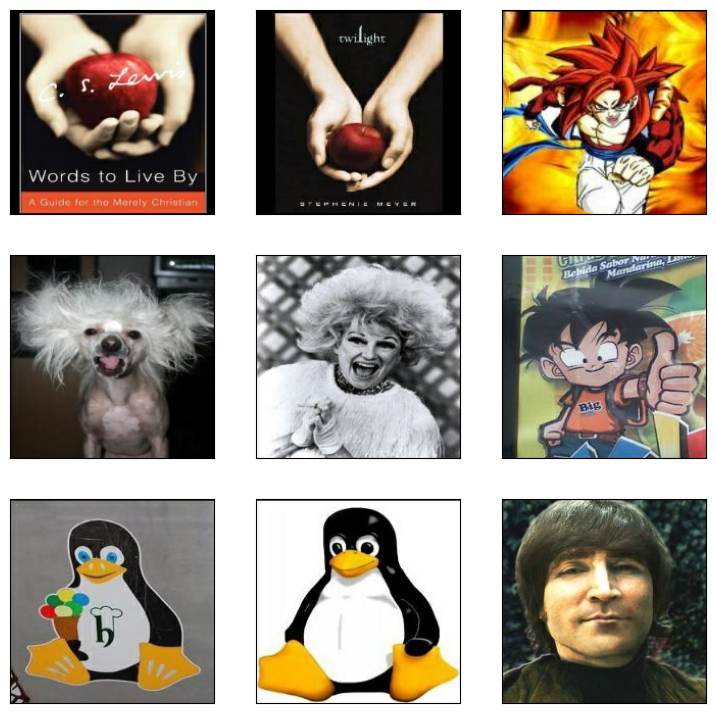

In [ ]:
siamese_model = SiameseModel(siamese_network)
#siamese_model = tf.keras.models.load_model(model_path, custom_objects={"VIT": VIT})
siamese_model.compile(optimizer=optimizers.Adam(0.0001))
siamese_model.fit(train_dataset, epochs=epochs, validation_data=val_dataset)

sample = next(iter(train_dataset))
visualize(*sample)

anchor, positive, negative = sample
anchor_embedding, positive_embedding, negative_embedding = (
    embedding(resnet.preprocess_input(anchor)),
    embedding(resnet.preprocess_input(positive)),
    embedding(resnet.preprocess_input(negative)),
)

cosine_similarity = metrics.CosineSimilarity()

positive_similarity = cosine_similarity(anchor_embedding, positive_embedding)
print("Positive similarity:", positive_similarity.numpy())

negative_similarity = cosine_similarity(anchor_embedding, negative_embedding)
print("Negative similarity", negative_similarity.numpy())

embedding.save(f"{bgPath}/siam.h5")

In [ ]:
siam_model = tf.keras.models.load_model(model_path, custom_objects={"VIT": VIT})
siam_model.summary()

Model: "Embedding"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200, 200, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 206, 206, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 100, 100, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 100, 100, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                      

In [ ]:
files = []
for f in os.listdir(pic_path):
  if f.endswith('.jpg'):
    files.append(f'{pic_path}/{f}')
def getEmbeddings(model, root_folder):
  #files = [f'{root_folder}/{f}' if f.endswith('.jpg') for f in os.listdir(root_folder)]
  dataset = tf.data.Dataset.from_tensor_slices(files)
  dataset = dataset.map(preprocess_image)
  dataset = dataset.batch(32)
  embeddings = model.predict(dataset)
  return embeddings

embeddings = getEmbeddings(siam_model, pic_path)

print(embeddings.shape)

108/108 [==============================] - 886s 8s/step
(3450, 256)


In [ ]:
def find_top_k(path, k):
  image = preprocess_image(path)
  image = tf.expand_dims(image, axis=0)
  single = siam_model.predict(image)
  remain = tf.reduce_sum(tf.square(embeddings - single), axis=1)
  smallest_indices = tf.argsort(remain)[:k]
  return smallest_indices

1/1 [==============================] - 1s 905ms/step
[2645  487 2165 1839  853]


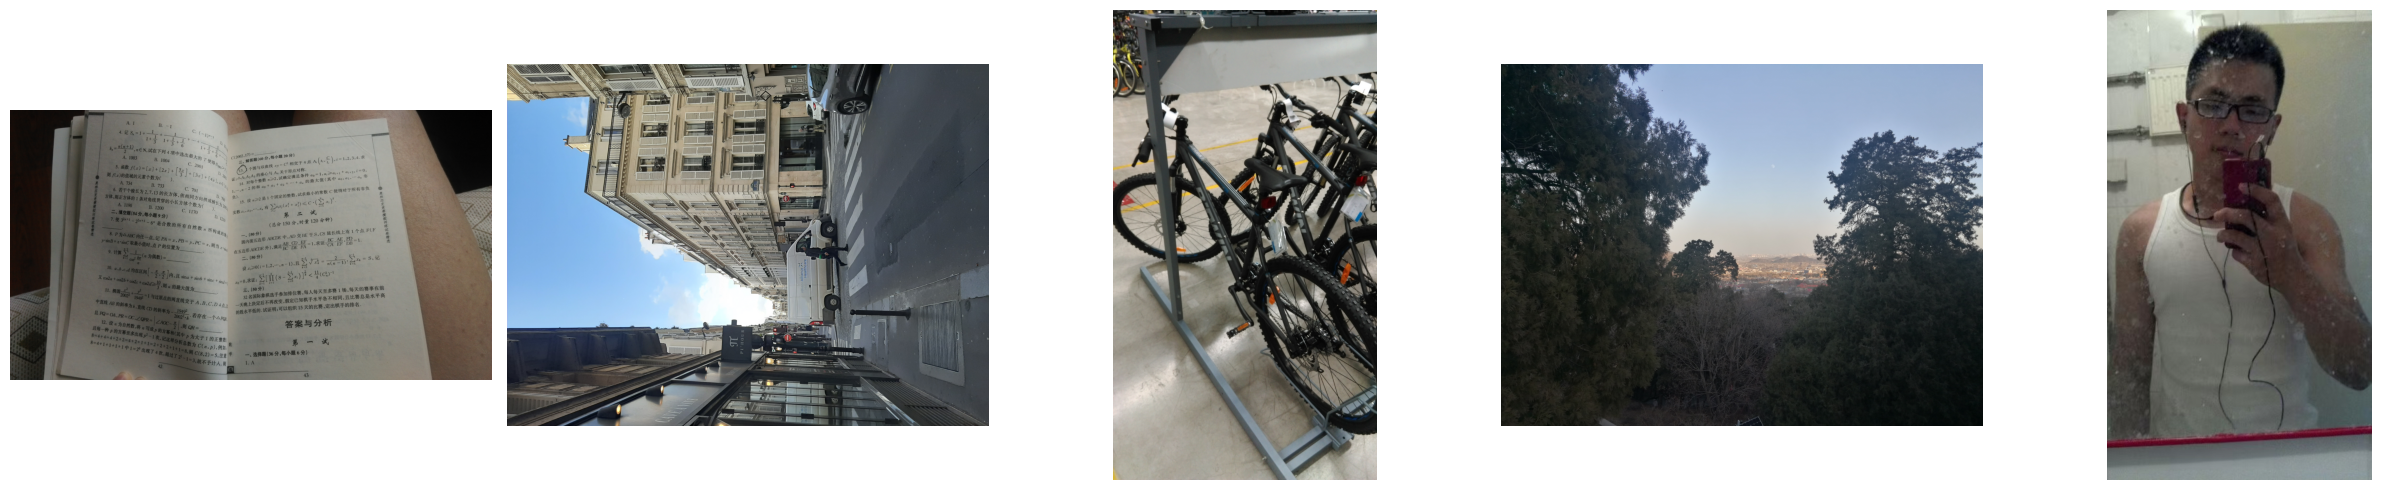

In [ ]:
pic_path = 'sample_data/county.jpg'
indexes = find_top_k(pic_path, 5).numpy()
print(indexes)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of image paths
image_paths = [files[i] for i in indexes]

# Number of images
num_images = len(image_paths)

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(num_images * 5, 5))

# Check if there is more than one image to display
if num_images > 1:
    for ax, img_path in zip(axes, image_paths):
        img = mpimg.imread(img_path)  # Load the image from the path
        ax.imshow(img)  # Display the image
        ax.axis('off')  # Hide axes
else:
    img = mpimg.imread(image_paths[0])
    axes.imshow(img)
    axes.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

## Summary

1. The `tf.data` API enables you to build efficient input pipelines for your model. It is
particularly useful if you have a large dataset. You can learn more about `tf.data`
pipelines in [tf.data: Build TensorFlow input pipelines](https://www.tensorflow.org/guide/data).

2. In this example, we use a pre-trained ResNet50 as part of the subnetwork that generates
the feature embeddings. By using [transfer learning](https://www.tensorflow.org/guide/keras/transfer_learning?hl=en),
we can significantly reduce the training time and size of the dataset.

3. Notice how we are [fine-tuning](https://www.tensorflow.org/guide/keras/transfer_learning?hl=en#fine-tuning)
the weights of the final layers of the ResNet50 network but keeping the rest of the layers untouched.
Using the name assigned to each layer, we can freeze the weights to a certain point and keep the last few layers open.

4. We can create custom layers by creating a class that inherits from `tf.keras.layers.Layer`,
as we did in the `DistanceLayer` class.

5. We used a cosine similarity metric to measure how to 2 output embeddings are similar to each other.

6. You can implement a custom training loop by overriding the `train_step()` method. `train_step()` uses
[`tf.GradientTape`](https://www.tensorflow.org/api_docs/python/tf/GradientTape),
which records every operation that you perform inside it. In this example, we use it to access the
gradients passed to the optimizer to update the model weights at every step. For more details, check out the
[Intro to Keras for researchers](https://keras.io/getting_started/intro_to_keras_for_researchers/)
and [Writing a training loop from scratch](https://www.tensorflow.org/guide/keras/writing_a_training_loop_from_scratch?hl=en).